# Shanghai 1905 Flood – New Experiment Analysis

Analyzes the new `postproc/` model runs. Uses `infil_7_890_rain` sub-folder for all four experiments.

| Folder | Scenario |
|--------|----------|
| `new_postproc1/infil_7_890_rain` | ctrl (baseline) |
| `new_postproc2/infil_7_890_rain` | norain1 (no rain #1) |
| `new_postproc3/infil_7_890_rain` | norain2 (no rain #2) |
| `new_postproc4/infil_7_890_rain` | no rain at all (new) |

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib import animation
from matplotlib.animation import FFMpegWriter, PillowWriter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
from shapely.geometry import MultiPolygon, LineString, Point
from pyproj import Transformer
from scipy.stats import binned_statistic_2d
import contextily as ctx
import matplotlib as mpl

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

mpl.rcParams.update({'font.size': 8})

# ── Paths ──────────────────────────────────────────────────────────────────
base_dir      = "/Users/shwang/sandbox/shanghai"
shape_dir     = f"{base_dir}/map/1910map/shape"
gadm_path     = "/Users/shwang/sandbox/data/borders/gadm36.shp"
rain_path     = f"{base_dir}/xujiahui_aug2031_daily_rain.csv"
river_mask_path = f"{base_dir}/river_mask.xyz"
river_dir     = f"{base_dir}/市管河道/"

postproc_dir  = f"{base_dir}/postproc"
EXP_SUB       = "infil_7_890_rain"  # sub-folder to use in every new_postproc*

scenario_dirs = {
    "CTRL"           : f"{postproc_dir}/new_postproc1/{EXP_SUB}/text",
    "No Rain #1"     : f"{postproc_dir}/new_postproc2/{EXP_SUB}/text",
    "No Rain #2"     : f"{postproc_dir}/new_postproc3/{EXP_SUB}/text",
    "No Rain At All" : f"{postproc_dir}/new_postproc4/{EXP_SUB}/text",
}
scenario_colors = {
    "CTRL"           : "C0",
    "No Rain #1"     : "C1",
    "No Rain #2"     : "C2",
    "No Rain At All" : "C3",
}

# ── Rainfall data ──────────────────────────────────────────────────────────
rain = pd.read_csv(rain_path, sep=",")
rain["date"]     = pd.to_datetime(dict(year=rain.Year, month=rain.Mon, day=rain.Day))
rain["daily_mm"] = rain["daily_acc_10thmm"] / 10.0
rain["md"]       = rain["date"].dt.strftime("%m-%d")

mask = (
    ((rain["date"].dt.month == 8) & (rain["date"].dt.day >= 20)) |
    ((rain["date"].dt.month == 9) & (rain["date"].dt.day <= 5))
)
rain_subset  = rain.loc[mask].copy()
ordered_days = sorted(rain_subset["md"].unique(), key=lambda x: pd.to_datetime("1900-" + x))
rain_subset["md"] = pd.Categorical(rain_subset["md"], categories=ordered_days, ordered=True)
rain_subset  = rain_subset[rain_subset["md"].between("08-20", "09-02")]
ordered_days = sorted(rain_subset["md"].unique(), key=lambda x: pd.to_datetime("1900-" + x))
rain_1905    = rain_subset[rain_subset["Year"] == 1905]

# ── Historical map layers ──────────────────────────────────────────────────
圩塘     = gpd.read_file(f"{shape_dir}/圩塘.shp")
海岸线   = gpd.read_file(f"{shape_dir}/海岸线.shp")
钦公塘   = gpd.read_file(f"{shape_dir}/钦公塘.shp")
雍正石塘 = gpd.read_file(f"{shape_dir}/雍正石塘.shp")
市管河道 = gpd.read_file(f"{river_dir}/市管河道.shp").set_crs(epsg=4326, inplace=False)

# ── GADM – Shanghai main polygon + inland border ───────────────────────────
gadm     = gpd.read_file(gadm_path)
sh_parts = gadm[(gadm["NAME_0"] == "China") & (gadm["NAME_2"] == "Shanghai")]
sh_dissolved = sh_parts.dissolve()
geom = sh_dissolved.geometry.iloc[0]
if isinstance(geom, MultiPolygon):
    main_poly    = max(geom.geoms, key=lambda p: p.area)
    shanghai_main = gpd.GeoDataFrame(geometry=[main_poly], crs=sh_dissolved.crs)
else:
    shanghai_main = sh_dissolved

other_regions     = gadm[(gadm["NAME_0"] == "China") & (gadm["NAME_2"] != "Shanghai")]
china_other       = other_regions.dissolve()
shanghai_boundary = gpd.GeoDataFrame(geometry=shanghai_main.boundary,  crs=shanghai_main.crs)
china_other_boundary = gpd.GeoDataFrame(geometry=china_other.boundary, crs=china_other.crs)
inland_border     = gpd.overlay(shanghai_boundary, china_other_boundary, how="intersection")

# ── River mask ─────────────────────────────────────────────────────────────
river_mask_df  = pd.read_csv(river_mask_path, sep=r"\s+", header=None,
                             names=["lon", "lat", "depth"])
river_coords   = set(zip(river_mask_df["lon"], river_mask_df["lat"]))

# ── Reproject static layers to EPSG:3857 ───────────────────────────────────
for layer in [圩塘, 海岸线, 钦公塘, 雍正石塘, 市管河道, shanghai_main, inland_border]:
    layer.to_crs(epsg=3857, inplace=True)

# ── Coastline-based inland filter ──────────────────────────────────────────
coastline_line = 海岸线.geometry.union_all()
if coastline_line.geom_type == "MultiLineString":
    coastline_line = LineString(
        np.concatenate([np.array(g.coords) for g in coastline_line.geoms])
    )
coast_coords = np.array(coastline_line.coords)
coast_coords = coast_coords[np.argsort(coast_coords[:, 1])]
unique_lat, idx = np.unique(coast_coords[:, 1], return_index=True)
interp_func = dict(zip(unique_lat, coast_coords[idx, 0]))

def clean_outsiders(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    pts = gdf.copy()
    pts["coast_x"] = np.interp(
        pts.geometry.y,
        np.array(list(interp_func.keys())),
        np.array(list(interp_func.values()))
    )
    return pts[pts.geometry.x <= pts["coast_x"]].copy()

# ── Helper: load one XYZ timestep ──────────────────────────────────────────
def data_load(path: str) -> gpd.GeoDataFrame:
    df  = pd.read_csv(path, sep=r"\s+", header=None, names=["lon", "lat", "depth"])
    df  = df[~df[["lon", "lat"]].apply(tuple, axis=1).isin(river_coords)]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
    gdf = gdf.to_crs(epsg=3857)
    gdf = clean_outsiders(gdf)
    return gdf

# ── Spatial grid constants (computed once at t=2) ──────────────────────────
lon_min, lon_max = 120.9, 122.0
lat_min, lat_max = 30.66, 31.52
corners = gpd.GeoDataFrame(
    geometry=[Point(lon_min, lat_min), Point(lon_min, lat_max),
              Point(lon_max, lat_max), Point(lon_max, lat_min)],
    crs="EPSG:4326"
).to_crs(epsg=3857)
x_range = [corners.geometry.x.min(), corners.geometry.x.max()]
y_range = [corners.geometry.y.min(), corners.geometry.y.max()]

print("Setup complete.")

Setup complete.


## 1. Percent Flooded Over Time
Computes the fraction of the Shanghai land area flooded above several depth thresholds for each scenario.

In [2]:
scenario_names = list(scenario_dirs.keys())
n_scen = len(scenario_names)

percent_flooded_1cm   = [[] for _ in range(n_scen)]
percent_flooded_10cm  = [[] for _ in range(n_scen)]
percent_flooded_50cm  = [[] for _ in range(n_scen)]
percent_flooded_100cm = [[] for _ in range(n_scen)]
percentile_50th       = [[] for _ in range(n_scen)]
percentile_95th       = [[] for _ in range(n_scen)]

total_n_inside = None
shanghai_main_3857 = shanghai_main.to_crs(epsg=3857)

for t_rec in np.arange(2, 359):
    print(t_rec, end=" ")

    for i, name in enumerate(scenario_names):
        path = os.path.join(scenario_dirs[name], f"t{int(t_rec)}.xyz")
        gdf  = data_load(path)
        depth_within = gpd.sjoin(gdf, shanghai_main_3857, how="inner", predicate="within")

        stat, xedges, yedges, _ = binned_statistic_2d(
            depth_within.geometry.x, depth_within.geometry.y, depth_within["depth"],
            statistic="mean", bins=100, range=[x_range, y_range]
        )
        z = np.nan_to_num(stat, nan=0).T.ravel()

        if total_n_inside is None:
            x_centers = (xedges[:-1] + xedges[1:]) / 2
            y_centers = (yedges[:-1] + yedges[1:]) / 2
            Xc, Yc = np.meshgrid(x_centers, y_centers)
            hex_centers = gpd.GeoSeries(
                [Point(x, y) for x, y in zip(Xc.ravel(), Yc.ravel())],
                crs="EPSG:3857"
            )
            inside_mask    = hex_centers.within(shanghai_main_3857.geometry.iloc[0])
            total_n_inside = inside_mask.sum()

        percent_flooded_1cm   [i].append(sum(z > 0.01) / total_n_inside)
        percent_flooded_10cm  [i].append(sum(z > 0.10) / total_n_inside)
        percent_flooded_50cm  [i].append(sum(z > 0.50) / total_n_inside)
        percent_flooded_100cm [i].append(sum(z > 1.00) / total_n_inside)
        wet = z[z > 0]
        percentile_50th[i].append(np.percentile(wet, 50) if len(wet) > 0 else 0)
        percentile_95th[i].append(np.percentile(wet, 95) if len(wet) > 0 else 0)

rows = np.arange(2, 359)

summary_df_percent_flooded_1cm   = pd.DataFrame(np.array(percent_flooded_1cm  ).T, index=rows, columns=scenario_names)
summary_df_percent_flooded_10cm  = pd.DataFrame(np.array(percent_flooded_10cm ).T, index=rows, columns=scenario_names)
summary_df_percent_flooded_50cm  = pd.DataFrame(np.array(percent_flooded_50cm ).T, index=rows, columns=scenario_names)
summary_df_percent_flooded_100cm = pd.DataFrame(np.array(percent_flooded_100cm).T, index=rows, columns=scenario_names)
summary_df_percentile_50th       = pd.DataFrame(np.array(percentile_50th      ).T, index=rows, columns=scenario_names)
summary_df_percentile_95th       = pd.DataFrame(np.array(percentile_95th      ).T, index=rows, columns=scenario_names)

print("\nDone.")

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 27

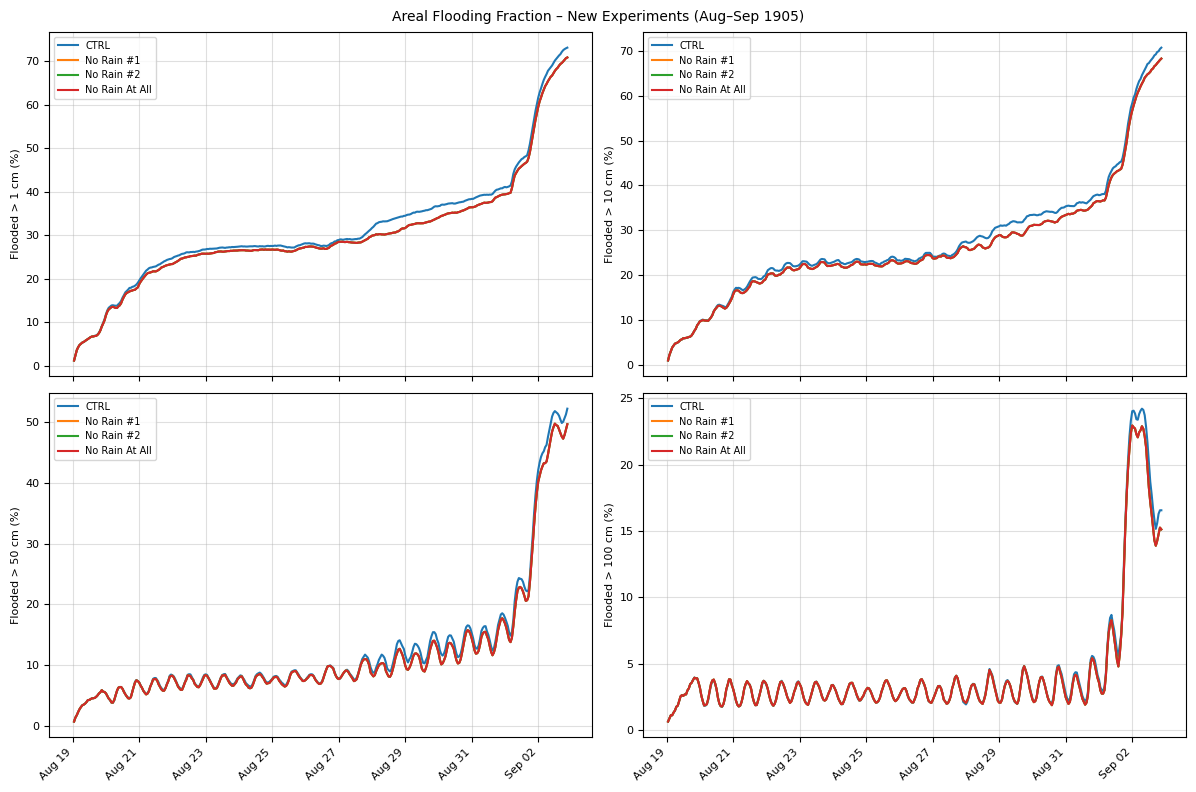

In [3]:
# Plot flooded area time series
start_time = pd.Timestamp("1905-08-19 01:00:00")
time_index = pd.date_range(start=start_time, periods=len(rows), freq="h")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
datasets = [
    (summary_df_percent_flooded_1cm,   "Flooded > 1 cm (%)"),
    (summary_df_percent_flooded_10cm,  "Flooded > 10 cm (%)"),
    (summary_df_percent_flooded_50cm,  "Flooded > 50 cm (%)"),
    (summary_df_percent_flooded_100cm, "Flooded > 100 cm (%)"),
]
for ax, (df, title) in zip(axes.flat, datasets):
    df_plot = df.copy()
    df_plot.index = time_index
    for name in scenario_names:
        ax.plot(time_index, df_plot[name] * 100, label=name,
                color=scenario_colors[name])
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=7)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle("Areal Flooding Fraction – New Experiments (Aug–Sep 1905)", fontsize=10)
plt.tight_layout()
plt.savefig("Fig_postproc_flooded_area.pdf", bbox_inches="tight")
plt.show()

## 2. Scenario Difference Analysis
For each no-rain scenario, computes the fraction of the domain where depth increases or decreases
by more than 5 cm relative to the new ctrl.

In [5]:
comparison_scenarios = ["No Rain #1", "No Rain #2", "No Rain At All"]

percent_increase = {s: [] for s in comparison_scenarios}
percent_decrease = {s: [] for s in comparison_scenarios}

total_n_inside = None

for t_rec in np.arange(2, 359):
    print(t_rec, end=" ")

    ctrl_path = os.path.join(scenario_dirs["CTRL"], f"t{int(t_rec)}.xyz")
    ctrl_gdf  = data_load(ctrl_path)
    ctrl_within = gpd.sjoin(ctrl_gdf, shanghai_main_3857, how="inner", predicate="within")

    stat_ctrl, xedges, yedges, _ = binned_statistic_2d(
        ctrl_within.geometry.x, ctrl_within.geometry.y, ctrl_within["depth"],
        statistic="mean", bins=100, range=[x_range, y_range]
    )
    z_ctrl = np.nan_to_num(stat_ctrl, nan=0)

    if total_n_inside is None:
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        Xc, Yc = np.meshgrid(x_centers, y_centers)
        hex_centers = gpd.GeoSeries(
            [Point(x, y) for x, y in zip(Xc.ravel(), Yc.ravel())],
            crs="EPSG:3857"
        )
        inside_mask    = hex_centers.within(shanghai_main_3857.geometry.iloc[0])
        total_n_inside = inside_mask.sum()

    for s in comparison_scenarios:
        path = os.path.join(scenario_dirs[s], f"t{int(t_rec)}.xyz")
        gdf  = data_load(path)
        within = gpd.sjoin(gdf, shanghai_main_3857, how="inner", predicate="within")

        stat, _, _, _ = binned_statistic_2d(
            within.geometry.x, within.geometry.y, within["depth"],
            statistic="mean", bins=[xedges, yedges]
        )
        z_scen = np.nan_to_num(stat, nan=0)
        diff   = (z_scen - z_ctrl).ravel()

        percent_increase[s].append(sum(diff >  0.05) / total_n_inside)
        percent_decrease[s].append(sum(diff < -0.05) / total_n_inside)

rows = np.arange(2, 359)
summary_df_percent_increase = pd.DataFrame(percent_increase, index=rows)
summary_df_percent_decrease = pd.DataFrame(percent_decrease, index=rows)

print("\nDone.")

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 27

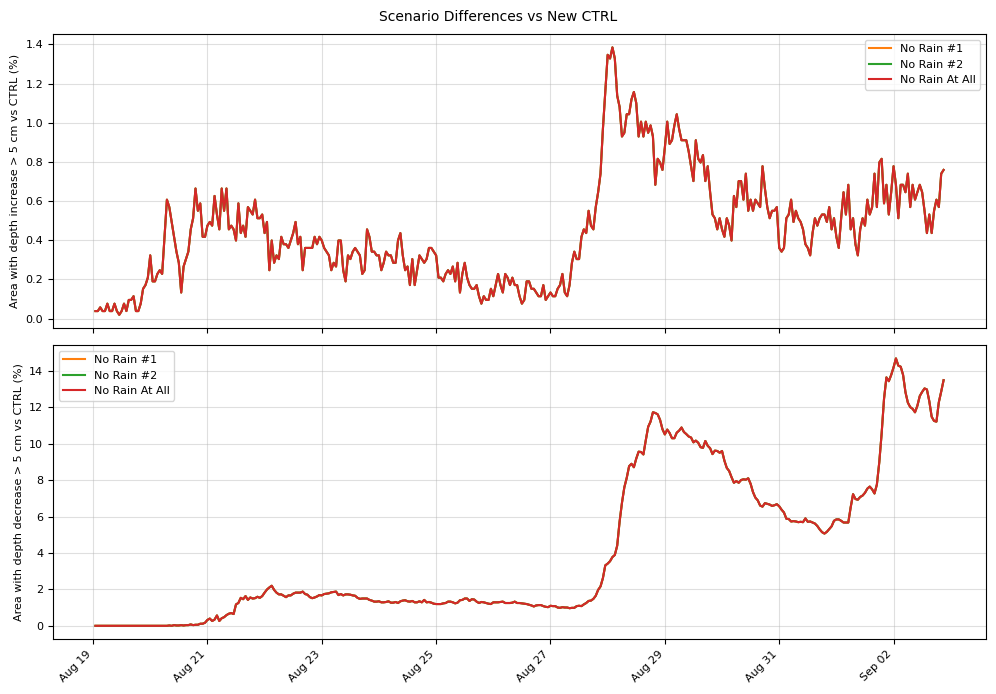

In [6]:
start_time = pd.Timestamp("1905-08-19 01:00:00")
time_index = pd.date_range(start=start_time, periods=len(rows), freq="h")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for s, c in zip(comparison_scenarios, ["C1", "C2", "C3"]):
    ax1.plot(time_index, np.array(percent_increase[s]) * 100, label=s, color=c)
    ax2.plot(time_index, np.array(percent_decrease[s]) * 100, label=s, color=c)

for ax, title in zip([ax1, ax2], [
    "Area with depth increase > 5 cm vs CTRL (%)",
    "Area with depth decrease > 5 cm vs CTRL (%)"
]):
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle("Scenario Differences vs New CTRL", fontsize=10)
plt.tight_layout()
plt.savefig("Fig_postproc_diff.pdf", bbox_inches="tight")
plt.show()

## 3. Flood Animation – New CTRL
Produces a 2-panel animation (rainfall + tide time series on the left, depth map on the right)
using the new ctrl experiment (`new_postproc1/infil_7_890_rain`).

In [ ]:
# ── Custom colormap ─────────────────────────────────────────────────────────
def shuai_colormap1():
    C1 = np.asarray([170, 219,  30]) / 255
    C2 = np.asarray([  2,   7,  93]) / 255
    C3 = np.asarray([  0, 183, 235]) / 255
    C9 = np.asarray([240, 255, 255]) / 255
    tmp1 = np.array([[*[np.linspace(C1[k], C2[k], 10)[i] for k in range(3)]] for i in range(9)])
    tmp2 = np.array([[*[np.linspace(C2[k], C3[k],  8)[i] for k in range(3)]] for i in range(7)])
    tmp4 = np.array([[*[np.linspace(C3[k], C9[k],  4)[i] for k in range(3)]] for i in range(4)])
    colors_arr = np.concatenate([tmp1, tmp2, tmp4])
    cmap_base  = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors_arr)
    return cmap_base.reversed()

cmap = shuai_colormap1()
norm = mcolors.Normalize(vmin=0, vmax=1.2)

# ── Tide / water level data ─────────────────────────────────────────────────
def fix_year(d):
    parts = d.split()
    date_parts = parts[0].split("/")
    if len(date_parts[2]) == 2:
        date_parts[2] = "19" + date_parts[2]
    return "/".join(date_parts) + " " + parts[1]

tide_obs = pd.read_csv(f"{base_dir}/wusongkou.csv")
tide_obs.columns = tide_obs.columns.str.strip()
tide_obs["fixed_date"] = tide_obs["date and time"].apply(fix_year)
tide_obs["datetime"]   = pd.to_datetime(tide_obs["fixed_date"], format="%m/%d/%Y %H:%M")
tide_obs["depth_m"]    = tide_obs["water depth (points) (m)"]
mask_obs = (
    (tide_obs["datetime"] >= "1905-08-19 00:00") &
    (tide_obs["datetime"] <= "1905-09-02 21:00")
)
tide_plot = tide_obs.loc[mask_obs].copy()

tide_mod = pd.read_csv(f"{base_dir}/Wusong_tide_modeling_19050801-19050916.csv")
tide_mod.columns = tide_mod.columns.str.strip()
tide_mod["fixed_date"] = tide_mod["date and time"].apply(fix_year)
tide_mod["datetime"]   = pd.to_datetime(tide_mod["fixed_date"], format="%m/%d/%Y %H:%M")
tide_mod["depth_m"]    = tide_mod["water depth (points) (m)"]
mask_mod = (
    (tide_mod["datetime"] >= "1905-08-19 00:00") &
    (tide_mod["datetime"] <= "1905-09-02 21:00")
)
tide_plot_tide = tide_mod.loc[mask_mod].copy()
tide_plot_tide["depth_m"] += 2.4

tide_sorted = tide_plot.sort_values("datetime")
x_all = mdates.date2num(tide_sorted["datetime"])
y_all = tide_sorted["depth_m"]

# ── Rainfall series ─────────────────────────────────────────────────────────
rain_1905_sorted  = rain_1905.sort_values("md")
rain_1905_series  = rain_1905_sorted.set_index("md").loc[ordered_days]["daily_mm"].values
x_rain = pd.to_datetime(["1905-" + d for d in ordered_days])
color_bar = "#1f77b4"

# ── XYZ files for ctrl ──────────────────────────────────────────────────────
ctrl_xyz_dir = scenario_dirs["CTRL"]
xyz_files    = [os.path.join(ctrl_xyz_dir, f"t{i}.xyz") for i in range(1, 359)]
start_time   = pd.to_datetime("1905-08-19 00:00")
frame_times  = [start_time + pd.Timedelta(hours=i) for i in range(len(xyz_files))]

def load_xyz_anim(fname: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(fname, sep=r"\s+", header=None, names=["lon", "lat", "depth"])
    df = df[~df[["lon", "lat"]].apply(tuple, axis=1).isin(river_coords)]
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
    gdf = gdf.to_crs(epsg=3857)
    gdf = clean_outsiders(gdf)
    return gpd.sjoin(gdf, shanghai_main_3857, how="inner", predicate="within")

# ── Build figure ─────────────────────────────────────────────────────────────
fig, (ax_ts, ax_map) = plt.subplots(
    1, 2, figsize=(10, 4), dpi=200,
    gridspec_kw={"width_ratios": [1.1, 1.1]}
)

# Left panel
tick_dates = pd.date_range("1905-08-19", "1905-09-03")
ax_ts.bar(x_rain, rain_1905_series, color=color_bar)
ax_ts.set_ylim(0, 100)
ax_ts.set_ylabel("Daily Rainfall (mm)", color=color_bar)
ax_ts.tick_params(axis="y", colors=color_bar)
ax_ts.set_xlim(pd.to_datetime("1905-08-19 00:00"), pd.to_datetime("1905-09-03 00:00"))
ax_ts.set_xticks(tick_dates)
ax_ts.set_xticklabels([d.strftime("%m/%d") for d in tick_dates], rotation=45)

ax_ts_tide = ax_ts.twinx()
ax_ts_tide.plot(tide_plot["datetime"], tide_plot["depth_m"],
                color="#d62728", linewidth=1.5, label="Simulated water level")
ax_ts_tide.plot(tide_plot_tide["datetime"], tide_plot_tide["depth_m"],
                color="#FFD700", linewidth=0.8, label="Astronomical tide")
ax_ts_tide.set_ylim(0, 7)
ax_ts_tide.set_ylabel("Water Level (m)", color="#d62728")
ax_ts_tide.tick_params(axis="y", colors="#d62728")
ax_ts_tide.set_xlim(pd.to_datetime("1905-08-19 00:00"), pd.to_datetime("1905-09-03 00:00"))

x0 = mdates.date2num(frame_times[0])
y0 = np.interp(x0, x_all, y_all)
green_dot, = ax_ts_tide.plot(
    [mdates.num2date(x0)], [y0], marker="o", markersize=6, color="green", zorder=5
)
time_label_ts = ax_ts.text(
    0.50, 0.95, frame_times[0].strftime("Time: %Y-%m-%d %H:%M"),
    transform=ax_ts.transAxes, ha="center", va="top", fontsize=8, fontweight="bold"
)
ax_ts.legend(
    handles=[
        Patch(facecolor=color_bar, edgecolor="none", label="Rainfall"),
        Line2D([0], [0], color="#FFD700", lw=0.8, label="Astronomical tide"),
        Line2D([0], [0], color="#d62728", lw=1.5, label="Simulated water level"),
    ],
    loc="upper left", frameon=False
)

# Right panel – static elements
圩塘.plot(ax=ax_map, color="darkgoldenrod", edgecolor="none")
钦公塘.plot(ax=ax_map, color="darkgoldenrod", edgecolor="none", lw=2)
雍正石塘.plot(ax=ax_map, edgecolor="slategray", linewidth=3)
海岸线.plot(ax=ax_map, edgecolor="black", linewidth=1, linestyle="dashed")
inland_border.plot(ax=ax_map, edgecolor="black", linewidth=0.8)
市管河道[市管河道["MC"].isin([
    "黄浦江", "苏州河", "蕴藻浜", "淀浦河", "太浦河",
    "拦路港", "斜塘", "横潦泾", "西泖河", "泖河", "竖潦泾"
])].plot(ax=ax_map, edgecolor="magenta", linewidth=1, facecolor="none", zorder=20, alpha=0.5)
ctx.add_basemap(ax_map, source=ctx.providers.CartoDB.PositronNoLabels, attribution=False)

minx, miny, maxx, maxy = shanghai_main_3857.total_bounds
pad_x, pad_y = 0.02 * (maxx - minx), 0.02 * (maxy - miny)
ax_map.set_xlim(minx - pad_x, maxx + pad_x)
ax_map.set_ylim(miny - pad_y, maxy + pad_y)
ax_map.set_xticks([]); ax_map.set_yticks([])
ax_map.set_title("Simulated Water Depth – New CTRL", fontsize=9)

depth0 = load_xyz_anim(xyz_files[0])
hb = ax_map.hexbin(
    depth0.geometry.x, depth0.geometry.y, C=depth0["depth"],
    reduce_C_function=np.mean, gridsize=70, cmap=cmap, norm=norm, edgecolors="none"
)
hb.set_antialiased(False)
cbar = fig.colorbar(hb, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label("Water Depth (m)")

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
wx, wy = transformer.transform(121.5, 31.4)
ax_map.plot(wx, wy, marker="*", color="red", markersize=8, zorder=30)
ax_map.text(wx + 1500, wy + 1500, "Wusongkou", fontsize=8, color="red",
            ha="left", va="bottom", zorder=30,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
time_label_map = ax_map.text(
    0.02, 0.95, frame_times[0].strftime("%Y-%m-%d %H:%M"),
    transform=ax_map.transAxes, ha="left", va="top", fontsize=8, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
)

fig.tight_layout()

# ── Animation ─────────────────────────────────────────────────────────────
def update(frame):
    global hb
    t     = frame_times[frame]
    x_num = mdates.date2num(t)
    y_val = np.interp(x_num, x_all, y_all)
    green_dot.set_data([mdates.num2date(x_num)], [y_val])
    time_label_ts.set_text(t.strftime("Time: %Y-%m-%d %H:%M"))
    time_label_map.set_text(t.strftime("%Y-%m-%d %H:%M"))
    if hb is not None:
        hb.remove()
    depth = load_xyz_anim(xyz_files[frame])
    hb = ax_map.hexbin(
        depth.geometry.x, depth.geometry.y, C=depth["depth"],
        reduce_C_function=np.mean, gridsize=70, cmap=cmap, norm=norm, edgecolors="none"
    )
    hb.set_antialiased(False)
    return green_dot, hb, time_label_ts, time_label_map

anim = animation.FuncAnimation(fig, update, frames=len(xyz_files), interval=200, blit=False)
writer = FFMpegWriter(fps=10, metadata=dict(artist="Shanghai1905"), bitrate=3000)
anim.save("Shanghai_1905_flood_movie_new_ctrl.mp4", writer=writer, dpi=200)
plt.close(fig)
print("Saved: Shanghai_1905_flood_movie_new_ctrl.mp4")